<a href="https://colab.research.google.com/github/Adarshmalpotra/MALPOTRA/blob/main/ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

What is a model?
- code -> mathematical model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Ready set go. Today's new library is scikit-learn (sklearn)")

#predict an exam score from hours studied
# data/examples -> hours studied, score

# --- make some example data (in real life this is a CSV) ---
np.random.seed(1)
hours = np.random.uniform(0, 10, 60)
scores = 35 + 6*hours + np.random.normal(0, 6, 60)   # true trend + noise
scores = scores.clip(0, 100)
study = pd.DataFrame({"hours_studied": hours.round(1), "exam_score": scores.round(1)})
study.head()


Ready set go. Today's new library is scikit-learn (sklearn)


,hours_studied,exam_score
0,4.2,58.9
1,7.2,72.9
2,0.0,30.5
3,3.0,63.3
4,1.5,44.1


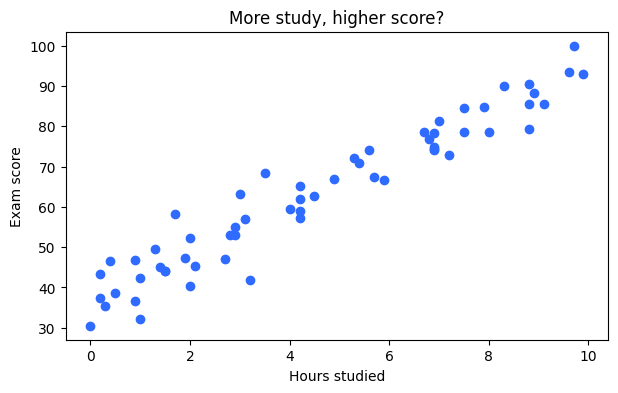

In [ ]:

# see the relationship first — always look before modelling
plt.figure(figsize=(7,4))
plt.scatter(study["hours_studied"], study["exam_score"], color="#2f6bff")
plt.xlabel("Hours studied"); plt.ylabel("Exam score"); plt.title("More study, higher score?")
plt.show()

In [ ]:
#Next we will start with the model and training it

from sklearn.linear_model import LinearRegression

x = study[["hours_studied"]]
y =  study[["exam_score"]]

model = LinearRegression() #created the model

model.fit(x,y)  #fit -> this is for learning or training the model

# Option 2: Using a pandas DataFrame
print(model.predict(pd.DataFrame({'hours_studied': [3]})))

[[54.22283228]]


In [ ]:
# Define the hours the user wants to predict for
hours_to_predict = [3, 2, 8, 4, 12, 16, 1]

# Create a DataFrame from these hours, as the model expects a 2D input
predict_df = pd.DataFrame({'hours_studied': hours_to_predict})

# Use the model to predict the exam scores for these hours
predicted_scores = model.predict(predict_df)

# Add the predicted scores to our DataFrame for easy viewing
predict_df['predicted_exam_score'] = predicted_scores

# --- New: Clip the predicted scores to be between 0 and 100 ---
predict_df['predicted_exam_score'] = predict_df['predicted_exam_score'].clip(0, 100)

# Display the results in a readable table
print("Here are the predicted exam scores based on hours studied (clipped to 0-100):")
display(predict_df)

Here are the predicted exam scores based on hours studied (clipped to 0-100):


,hours_studied,predicted_exam_score
0,3,54.222832
1,2,48.422283
2,8,83.225580
3,4,60.023382
4,12,100.000000
5,16,100.000000
6,1,42.621733


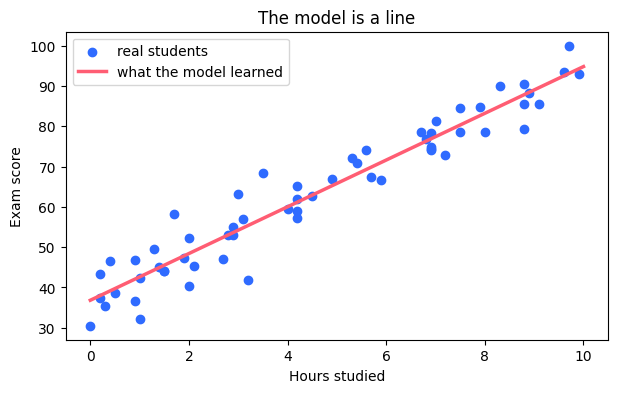

In [ ]:
# draw the line the model learned, over the data
line_x = pd.DataFrame({"hours_studied": np.linspace(0, 10, 100)})
plt.figure(figsize=(7,4))
plt.scatter(study["hours_studied"], study["exam_score"], color="#2f6bff", label="real students")
plt.plot(line_x["hours_studied"], model.predict(line_x), color="#ff5d73", linewidth=2.5, label="what the model learned")
plt.xlabel("Hours studied"); plt.ylabel("Exam score"); plt.legend(); plt.title("The model is a line")
plt.show()

In [ ]:
#The real thing: Predict House Prices of Flats

# Parameters: area, builder, age, amenities of the society, number of rooms, floor, balcony

# 4 parameters -> size -> sqft, bedroom, age, price

# More parameters means better predictibility when they have a corelation with the outcome


In [ ]:
np.random.seed(42) # For reproducibility

# Generate random data for house features
size_sqft = np.random.randint(500, 3000, 100) # Square footage between 500 and 3000
bedrooms = np.random.randint(1, 6, 100)       # Number of bedrooms between 1 and 5
age = np.random.randint(1, 50, 100)          # Age of the house between 1 and 50 years

# Generate price based on a linear relationship with features + some noise
# Assuming price increases with size, bedrooms, and decreases with age
price = (size_sqft * 50 + bedrooms * 20000 - age * 1000 + np.random.randn(100) * 50000).clip(50000, 2000000)

# Create a DataFrame for house data
house_data = pd.DataFrame({
    'size_sqft': size_sqft,
    'bedrooms': bedrooms,
    'age': age,
    'price': price
})

print("Generated house data:")
display(house_data.head())

print(f"Total number of elements in DataFrame: {house_data.size}")
print(f"Number of entries (rows) in DataFrame: {house_data.shape[0]}")

Generated house data:


,size_sqft,bedrooms,age,price
0,1360,2,9,167221.672366
1,1794,1,6,162301.445190
2,1630,5,16,146844.040517
3,1595,3,29,135929.853207
4,2138,4,3,323096.902324


Total number of elements in DataFrame: 400
Number of entries (rows) in DataFrame: 100


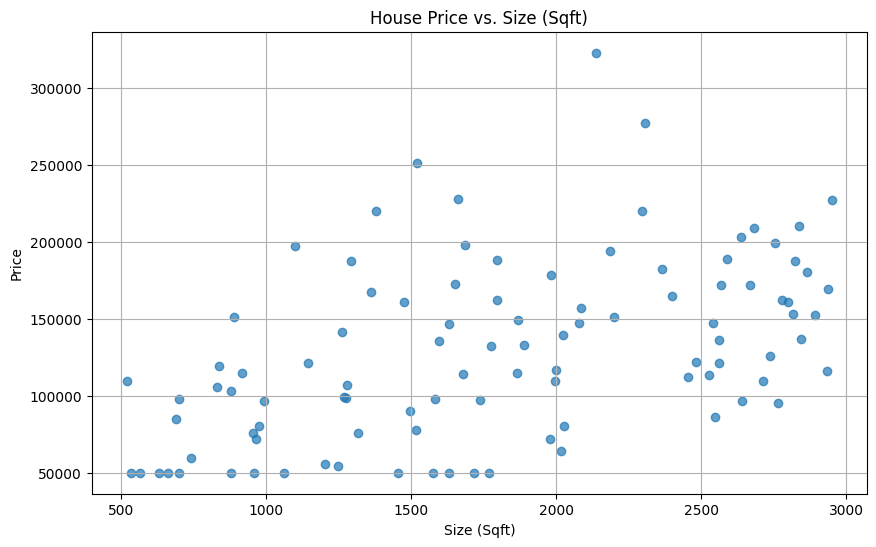

In [ ]:
# Visualize the generated house data (e.g., price vs. size_sqft)
plt.figure(figsize=(10, 6))
plt.scatter(house_data['size_sqft'], house_data['price'], alpha=0.7)
plt.title('House Price vs. Size (Sqft)')
plt.xlabel('Size (Sqft)')
plt.ylabel('Price')
plt.grid(True)
plt.show()

Now that we have our simulated house data, let's prepare it for our linear regression model. We'll split it into features (the `x` values: size, bedrooms, age) and the target (the `y` value: price).

In [ ]:
from sklearn.linear_model import LinearRegression

# Define features (X) and target (y)
X_house = house_data[['size_sqft', 'bedrooms', 'age']]
y_house = house_data['price']

# Initialize and train the Linear Regression model
house_model = LinearRegression()
house_model.fit(X_house, y_house)

print("House price prediction model trained successfully!")
print(f"Model coefficients: {house_model.coef_}")
print(f"Model intercept: {house_model.intercept_}")

House price prediction model trained successfully!
Model coefficients: [   38.09564235 16795.59868294  -992.43182693]
Model intercept: 37197.954327431726


Let's make a prediction for a new house. For example, a house with 1500 sqft, 3 bedrooms, and 10 years old.

In [ ]:
# Create a DataFrame for the new house's features
new_house_features = pd.DataFrame([[1500, 3, 10]], columns=['size_sqft', 'bedrooms', 'age'])

# Predict the price
predicted_house_price = house_model.predict(new_house_features)

print(f"Predicted price for a 1500 sqft, 3-bedroom, 10-year-old house: ${predicted_house_price[0]:,.2f}")

Predicted price for a 1500 sqft, 3-bedroom, 10-year-old house: $134,803.90


To see what the model has learned compared to the actual data, let's plot the actual house prices against the prices predicted by our model.

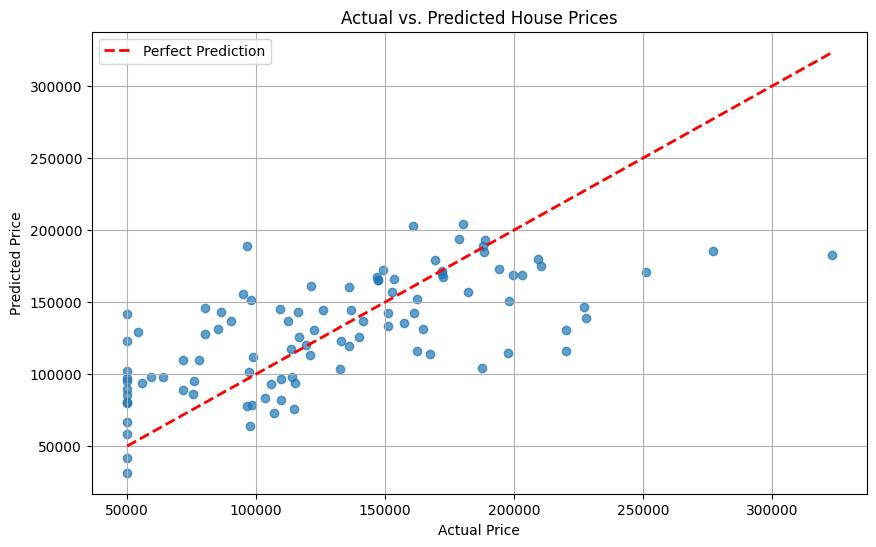

In [ ]:
# Get predictions for all houses in our dataset
all_house_predictions = house_model.predict(X_house)

# Plot actual vs. predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_house, all_house_predictions, alpha=0.7)
plt.plot([y_house.min(), y_house.max()], [y_house.min(), y_house.max()], 'r--', lw=2, label='Perfect Prediction') # Add a diagonal line for perfect prediction
plt.title('Actual vs. Predicted House Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.legend()
plt.show()

### Exploring a more advanced model: Random Forest Regressor

As discussed, linear regression might not fully capture the complex relationships in house pricing. Let's try a Random Forest Regressor, which is an ensemble learning method that can handle non-linearities and feature interactions better.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
# We'll use default parameters for now, but these can be tuned for better performance
rf_model = RandomForestRegressor(random_state=42) # random_state for reproducibility
rf_model.fit(X_house, y_house)

print("Random Forest Regressor model trained successfully!")

Random Forest Regressor model trained successfully!


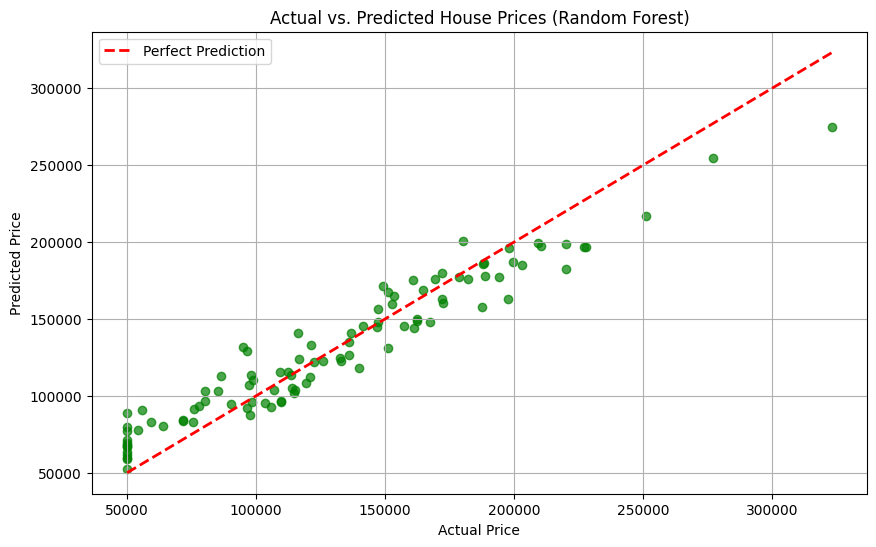

In [ ]:
# Get predictions from the Random Forest model for all houses in our dataset
rf_house_predictions = rf_model.predict(X_house)

# Plot actual vs. predicted prices for the Random Forest model
plt.figure(figsize=(10, 6))
plt.scatter(y_house, rf_house_predictions, alpha=0.7, color='green')
plt.plot([y_house.min(), y_house.max()], [y_house.min(), y_house.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs. Predicted House Prices (Random Forest)')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True)
plt.legend()
plt.show()

### Random Forest Model Prediction for a New House

Let's use our new Random Forest model to predict the price for the same example house we used with the Linear Regression model (1500 sqft, 3 bedrooms, 10 years old).

In [ ]:
# Predict the price for the new house using the Random Forest model
rf_predicted_house_price = rf_model.predict(new_house_features)

print(f"Predicted price for a 1500 sqft, 3-bedroom, 10-year-old house (Random Forest): ${rf_predicted_house_price[0]:,.2f}")

Predicted price for a 1500 sqft, 3-bedroom, 10-year-old house (Random Forest): $186,157.94


How is 1D better than 2D?? -> No
has AI has replaced coding -> Abstraction**
How will we reward AI?
How does prediction/data hallucinate??